In [35]:
import pandas as pd
import os

from ydata_profiling import ProfileReport

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
root_databases = '../01_databases/'

os.listdir(root_databases)

['dicionario_operadora_ativas_ans_03022025.csv',
 'operadora_ativas_ans_03022025.csv']

In [3]:
path_file = root_databases + 'operadora_ativas_ans_03022025.csv'

df = pd.read_csv(path_file)

In [4]:
df.shape

(1110, 21)

In [5]:
df['Data_Registro_ANS'] = df['Data_Registro_ANS'].astype('datetime64[ns]').dt.date

In [6]:
import seaborn
import matplotlib.pyplot as plt


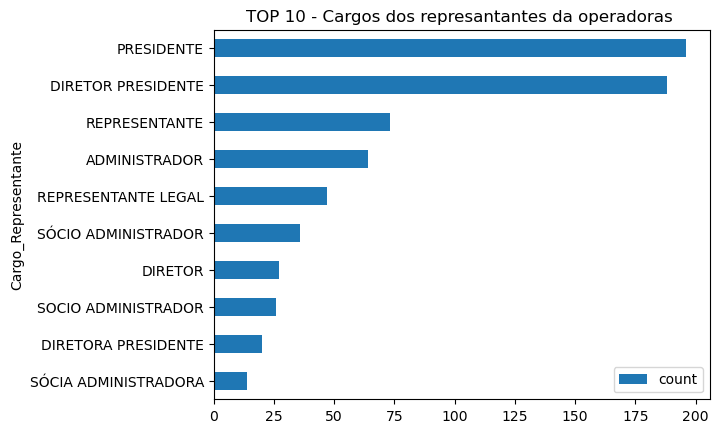

In [7]:
df[['Cargo_Representante']].value_counts().head(10).reset_index().sort_values('count').set_index('Cargo_Representante').plot.barh(title = 'TOP 10 - Cargos dos represantantes da operadoras ')

plt.show()

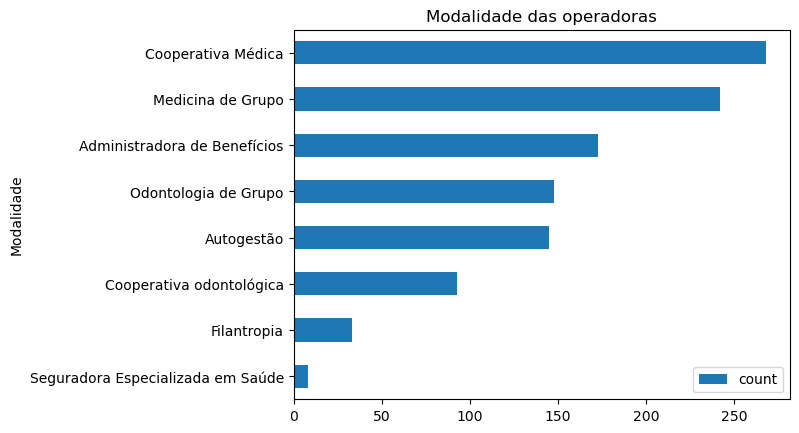

In [8]:
df[['Modalidade']].value_counts().reset_index().sort_values('count').set_index('Modalidade').plot.barh(title = 'Modalidade das operadoras')
plt.show()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1110 entries, 0 to 1109
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 1110 non-null   int64  
 1   Registro_ANS               1110 non-null   int64  
 2   CNPJ                       1110 non-null   int64  
 3   Razao_Social               1110 non-null   object 
 4   Nome_Fantasia              954 non-null    object 
 5   Modalidade                 1110 non-null   object 
 6   Logradouro                 1110 non-null   object 
 7   Numero                     1110 non-null   object 
 8   Complemento                548 non-null    object 
 9   Bairro                     1110 non-null   object 
 10  Cidade                     1110 non-null   object 
 11  UF                         1110 non-null   object 
 12  CEP                        1110 non-null   int64  
 13  DDD                        1004 non-null   float

In [11]:
df['Regiao_de_Comercializacao'].value_counts()

Regiao_de_Comercializacao
5.0    477
4.0    178
6.0    177
3.0     71
1.0     53
2.0     19
Name: count, dtype: int64

In [ ]:
df['ano_registro_ans'] = pd.to_datetime(df['Data_Registro_ANS']).dt.year
#

In [21]:
df.fillna({'ano_registro_ans':'1800'}, inplace = True)

df['ano_registro_ans'] = df['ano_registro_ans'].astype('int')

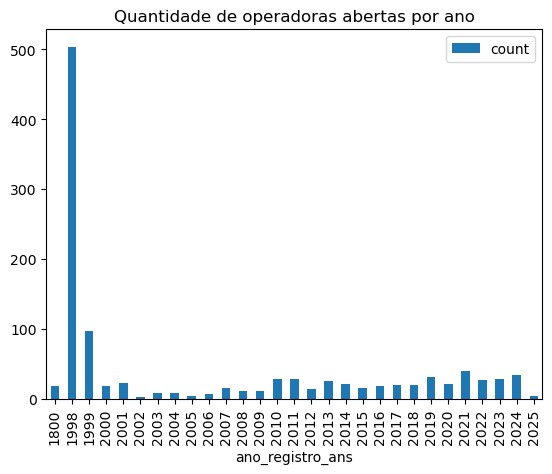

In [33]:
dplot = df[['ano_registro_ans']].sort_values('ano_registro_ans').value_counts(sort= False).reset_index()

dplot.set_index('ano_registro_ans').plot.bar(title = "Quantidade de operadoras abertas por ano")

plt.show()

In [50]:
sns.set_palette('mako')

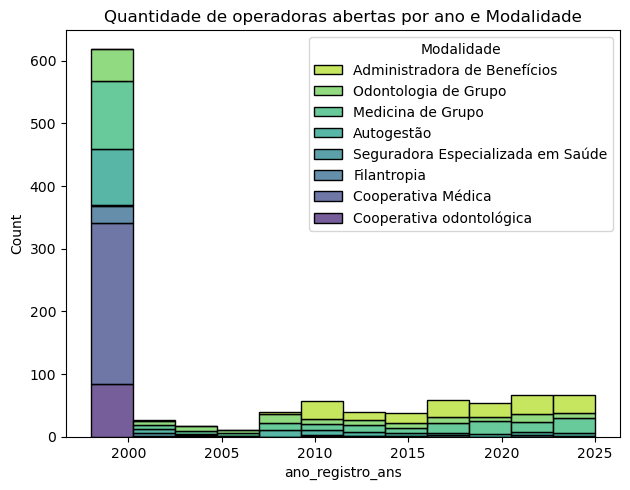

In [64]:
dplot = df[df['ano_registro_ans']>1900]

sns.histplot(dplot, x = 'ano_registro_ans', hue = 'Modalidade', multiple="stack", palette="viridis_r")

plt.tight_layout()
plt.title('Quantidade de operadoras abertas por ano e Modalidade')
plt.show()